# Ensemble Learning

## 1. 앙상블 학습이란?
> 다수의 `약한 학습기`를 조합하여 더욱 높은 성능 추출 
- `약한 학습기` : 단일 모델보다 약간 더 나은 성능을 보이는 모델

### 학습의 종류 
- `배깅(Bagging)` : 여러 모델을 병렬로 학습하여 예측 결과를 결합 (ex. 랜덤 포레스트) -> 분산 감소
- `부스팅(Boosting)` : 여러 모델을 순차적으로 학습하여 이전 모델의 오류를 보완 (ex. 그래디언트 부스팅, XGBoost) -> 편향 감소

### 배깅 
- `복원 추출` : 중복 Sampling을 통해 여러 개의 훈련 데이터셋 생성 
- b개의 독립 학습 셋 평균시 분산 $\frac{\sigma^2}{b}$ 감소 하면서 평균은 동일 
- `Aggregating` : 여러 모델의 예측 결과 중 투표하여 최종 예측 생성
- 대표 예시 : `Random Forest` (여러 개의 결정 트리를 사용하여 예측을 수행하는 앙상블 모델)

#### Bagging Tree 알고리즘 
- 훈련셋에서 랜덤 샘플링 -> $X_b, y_b$ 선택 
- $X_b, y_b$ 로 `ID3` 알고리즘으로 결정트리 구성 
- b개의 트리 생성 
- b개의 모든 트리를 이용하여 분류 진행 
- `majority voting` : b개의 트리에서 가장 많이 예측된 클래스를 최종 예측으로 선택
- 편향을 유지하면서 분산 감소 가능 

#### Random Forest 알고리즘
- Bagging Tree에서 발전 
- `bootstrap 샘플링` + `특성 무작위 선택`을 통한 트리 생성 
- Tree base 모델 -> white box 모델 특성 유지 
- 예측 정확도가 높음 
- 병렬적으로 생성 가능 및 빠른 예측 속도 
- 각 트리의 깊이가 깊게 생성 
  - 인위적으로 prune 을 하지 않으나 앙상블하면 낮은 편형과 낮은 분산 값을 얻음

### Boosting
> 미분류된 데이터에 더 높은 가중치를 부여하여 다음 번 모델의 Sampling에 포함될 확률을 높이는 방법

- 다수의 약한 학습자를 훈련시켜 majority voting하는 앙상블 기법 
- 예시 : `AdaBoost`(Adaptive Boosting), `Gradient Boosting`, `XGBoost` 등

#### Gradient Bootsting 알고리즘 
- 약한 학습자 (Weak Learner) : 랜덤 선택보다 약간 더 나은 성능의 모델 -> 결정 트리 사용 
- 이전 트리에서 발생한 `잔차(residual error)`를 다음 트리에서 보정
- 기존의 약한 학습자가 생성한 `잔차(residual error)`를 감소시키는 추가 트리를 더 이상 감소효과가 없을때 까지 생성 
- Gradient Descent(경사하강법)에 의해 손실함수(예시 : MSE)를 최적화 


#### AdaBoost
- `AdaBoost` : 여러개의 `Stump`을 조합하여 강한 학습자 생성
- `Stump` : 약한 학습자`들`  (기존의 약한학습자 단점 보완) 
- 이전 stump에서 잘못 분류한 데이터가 다음 샘플링에 포함되도록 가중치를 높음 

### RandomForest & GradientBoost 실습

#### 0) 실습 설명 

- 특정 사용자가 구매를 할지 여부 예측 
  - `1` : 구매
  - `0` : 구매하지 않음

|구분|설명|
|---|---|
|Dataset|datasets/Social_Network_Ads.csv|
|Features|User ID, Gender, Age, EstimatedSalary,Purchased|
|Target|구매 여부|
|Model|Random Forest, Gradient Boost|

#### 1) 필요 라이브러리 임포트

In [1]:
### 기본 라이브러리
import numpy as np
import pandas as pd

### 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

### 모델링 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

### 2) 데이터 불러오기

In [2]:
dataset = pd.read_csv("..\infran_ML_DL-main\datasets\Social_Network_Ads.csv")

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\skssk\AppData\Local\Temp\ipykernel_33612\1891580795.py:1: SyntaxWarning: invalid escape sequence '\i'
  dataset = pd.read_csv("..\infran_ML_DL-main\datasets\Social_Network_Ads.csv")


- 데이터 확인 
  - 사용할 데이터 : `Age`, `EstimatedSalary`, `Purchased`

In [3]:
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


- 총 데이터 수 확인 = 400개

In [4]:
dataset["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

### 3) 변수 선택
- 독립변수 X : Age, EstimatedSalary
- 종속변수 y : Purchased

In [ ]:
X = dataset.iloc[:, [2, 3]].values.astype("float32")
y = dataset.iloc[:, 4].values.astype("float32")

- 훈련셋과 테스트셋으로 분리 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (320, 2)
y_train shape:  (320,)
X_test shape:  (80, 2)
y_test shape:  (80,)


### 4) Feature Scaling

- 나이와 연봉은 서로 다른 단위 
- 조정이 없으면 연봉의 수가 크기 때문에 모델이 나이보다 연봉에 더 큰 영향을 받게 됨

In [ ]:
### 스케일러 선언 - 표준화
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### 5) 모델링 
- random forest 주요 파라미터 
  - 알고리즘 
  - 나무의 갯수 : 데이터가 많으면 1000개 이상 
  - 나무의 깊이

##### Random Forest 

In [ ]:
### 모델 선언 - 랜덤 포레스트
rf = RandomForestClassifier(n_estimators=10, random_state=0)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

#### Gradient Boosting Classifier

In [ ]:
gb = GradientBoostingClassifier(
    learning_rate=0.1, n_estimators=500, max_depth=5, random_state=0
)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

#### 6) 모델 예측

##### Random Forest 예측 

In [11]:
### 모델 예측
y_pred = rf.predict(X_test)

print("TEST SET의 True Positive : ", sum(y_pred == 1))
print("모델 예측 Positive : ", sum(y_pred))

TEST SET의 True Positive :  20
모델 예측 Positive :  20.0


##### 모델 예측 - 그레디언트 부스팅

In [12]:
### 모델 예측
y_pred_gb = gb.predict(X_test)

print("TEST SET의 True Positive : ", sum(y_pred_gb == 1))
print("모델 예측 Positive : ", sum(y_pred_gb))

TEST SET의 True Positive :  23
모델 예측 Positive :  23.0


### 7) 성능 평가

In [13]:
print("RF 정확도 : ", accuracy_score(y_test, y_pred))
print("GB 정확도 : ", accuracy_score(y_test, y_pred_gb))

RF 정확도 :  0.925
GB 정확도 :  0.9125


### 8) 시각화

- 색상 확인

In [ ]:
from matplotlib.colors import ListedColormap

# Create color maps
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])
cmap_bold = ListedColormap(["#FF0000", "#00FF00"])

- 그래프로 그려보기 

In [ ]:
x1_min, x1_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
x2_min, x2_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

X1, X2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1), np.arange(x2_min, x2_max, 0.1))
XX = np.column_stack([X1.ravel(), X2.ravel()])
Y_rf = np.array(rf.predict(XX))
Y_gb = np.array(gb.predict(XX))

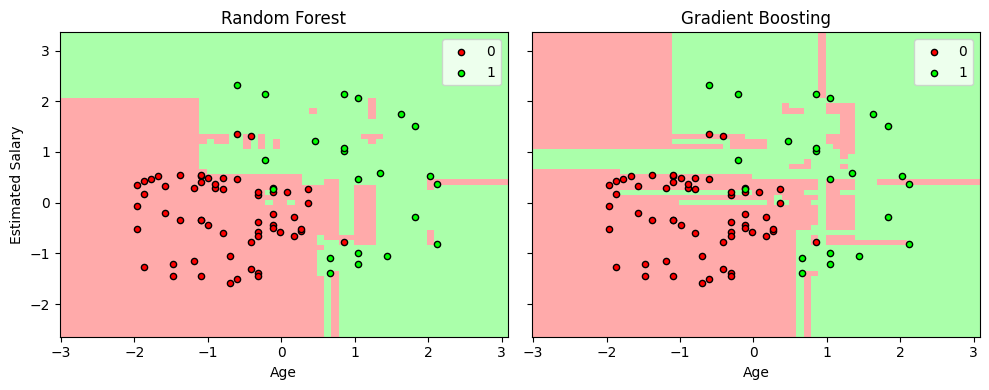

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Random Forest
ax1.pcolormesh(X1, X2, Y_rf.reshape(X1.shape), cmap=cmap_light, shading="auto")
for i in range(2):
    ax1.scatter(
        X_test[y_test == i, 0],
        X_test[y_test == i, 1],
        s=20,
        color=cmap_bold(i),
        label=i,
        edgecolor="k",
    )
ax1.set_title("Random Forest")
ax1.set_xlabel("Age")
ax1.set_ylabel("Estimated Salary")
ax1.legend()

# Gradient Boosting
ax2.pcolormesh(X1, X2, Y_gb.reshape(X1.shape), cmap=cmap_light, shading="auto")
for i in range(2):
    ax2.scatter(
        X_test[y_test == i, 0],
        X_test[y_test == i, 1],
        s=20,
        color=cmap_bold(i),
        label=i,
        edgecolor="k",
    )
ax2.set_title("Gradient Boosting")
ax2.set_xlabel("Age")
ax2.legend()
plt.tight_layout()

In [ ]:
gb.feature_importances_  # Age, EstimatedSalary 의 중요도

array([0.49456692, 0.50543308])

- 시각화

In [ ]:
feature_imp = pd.Series(
    gb.feature_importances_, ["Age", "EstimatedSalary"]
).sort_values(ascending=False)
feature_imp

EstimatedSalary    0.505433
Age                0.494567
dtype: float64

<Axes: title={'center': 'feature importance'}>

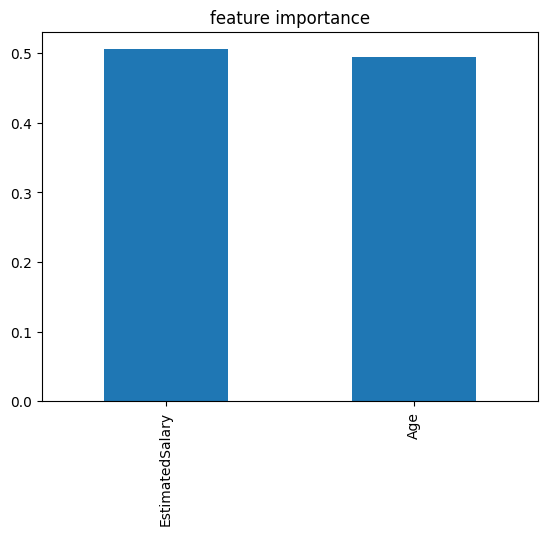

In [ ]:
feature_imp.plot(kind="bar", title="feature importance")